# 01 — AlphaEarth Embedding PCA Exploration

Fits PCA on the 64-dimensional AlphaEarth Foundations embeddings across all 2017 ice pixels, and produces the scree plot used in the paper (Figure 1) to motivate the use of raw embeddings (rather than a reduced PCA basis) as MLP/CNN input features.

All logic lives in `glacier_melt.sampling` and `glacier_melt.visualise`; this notebook only loads data, calls those functions, and displays results.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt

from glacier_melt.sampling import load_parquet_regions, fit_pca, sanity_check
from glacier_melt.visualise import plot_pca_scree

DATA_DIR = Path("../data/Training_Data_2017")  # adjust if parquets are stored elsewhere
OUTPUT_DIR = Path("../results")
OUTPUT_DIR.mkdir(exist_ok=True)

## Load 2017 training data

Loads all four regions (R1a, R1b, R2, R3) and runs basic sanity checks (null counts, AE band variance, ice/melt class separation).

In [2]:
df = load_parquet_regions(DATA_DIR)
sanity_check(df)

r1a: 6,222,913 pixels, 1.86 GB
r1b: 1,028,089 pixels, 0.31 GB
r2: 6,217,318 pixels, 1.85 GB
r3: 1,774,319 pixels, 0.53 GB

Combined: 15,242,639 pixels
Memory: 4.55 GB
Melt rate: 19.50%
=== STRUCTURE ===
Shape: (15242639, 72)
Columns: ['melt_label', 'elevation', 'aspect', 'slope', 'edge_distance', 'A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'lon', 'lat', 'region']

=== NULLS ===
No nulls anywhere ✓

=== ALPHAEARTH SUMMARY ===
Overall min: -0.4873
Overall max: 0.4764
Overall mean: -0.0181
Overall std: 0.1237

=== CONSTANT BANDS CHECK ===
All 64 AE bands have meaningful variance ✓
Std range: 

## Fit PCA on AlphaEarth embeddings

Fits a `StandardScaler` followed by PCA across all 64 embedding dimensions, using every 2017 ice pixel (Peru-wide). The fitted PCA and scaler are saved for use elsewhere in the pipeline (e.g. for the RF + AE PCA baseline model).

In [3]:
pca, scaler = fit_pca(
    df,
    n_components=64,
    save_path=OUTPUT_DIR / "ae_pca",
)

AE matrix: (15242639, 64), 3.90 GB
Standardised in 9.4s
PCA fit in 2.5s
  PC1-PC 1: 20.63% cumulative variance
  PC1-PC 3: 49.51% cumulative variance
  PC1-PC 6: 70.41% cumulative variance
  PC1-PC10: 81.48% cumulative variance
  PC1-PC20: 93.44% cumulative variance
  PC1-PC32: 97.63% cumulative variance
  PC1-PC64: 100.00% cumulative variance
Saved PCA and scaler to ..\results\ae_pca_*.joblib


## Scree plot (Figure 1)

Shows that no small number of principal components captures the majority of variance in the AlphaEarth embedding space — motivating the decision to use all 64 raw dimensions as MLP/CNN input rather than a reduced PCA basis.

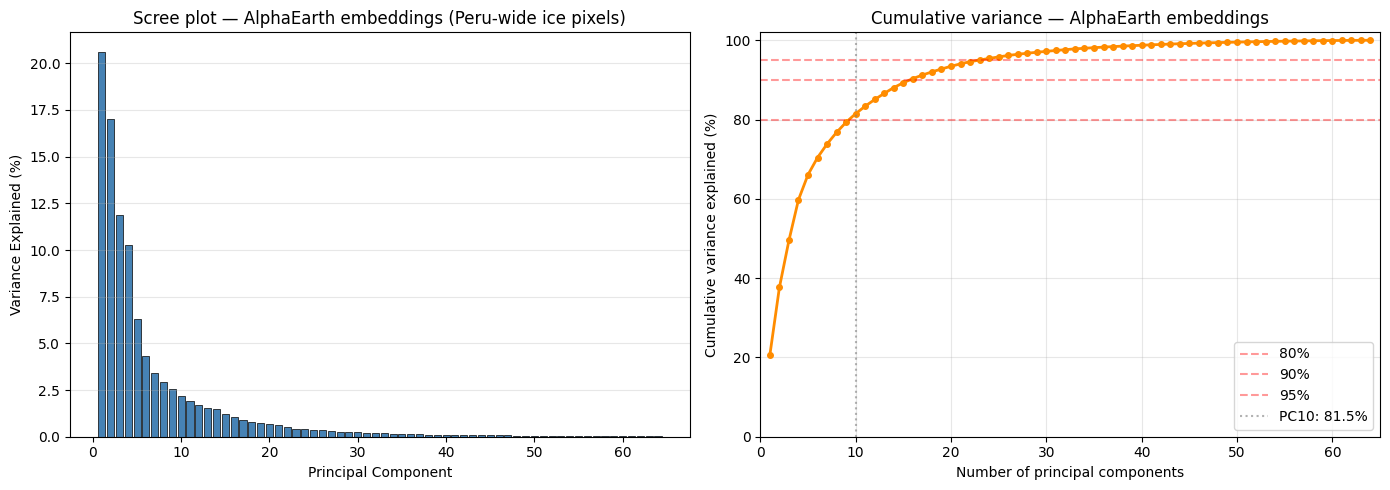

In [4]:
fig = plot_pca_scree(pca, n_components_highlight=10)
fig.savefig(OUTPUT_DIR / "pca_scree.png", dpi=200, bbox_inches="tight")
plt.show()